# Detecting DeepFakes

## Importing labraries

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Set GPU 'cuda' 

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Preprocessing

In [30]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Load data

In [31]:
data_dir = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'

train_ds = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
valid_ds = datasets.ImageFolder(os.path.join(data_dir, 'valid'), transform=val_transform)
test_ds  = datasets.ImageFolder(os.path.join(data_dir, 'test'),  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)

print(f"Train: {len(train_ds)} | Val: {len(valid_ds)} | Test: {len(test_ds)}")
print(f"Classes: {class_names}")

Train: 100000 | Val: 20000 | Test: 20000
Classes: ['fake', 'real']


In [32]:
import torchvision
print(torchvision.__version__)

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
print("EfficientNet import OK")

0.25.0+cu128
EfficientNet import OK


## Model Architecture 
We use **Transfer Learning**. Instead of building a model from scratch, we use **ResNet-18**, which already "knows" how to recognize shapes and textures. We simply replace the final layer to output a "Real" or "Fake" prediction.

In [33]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 3 blocks for fine-tuning
for name, param in model.named_parameters():
    if any(x in name for x in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True

# Replace classifier head
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 2),
    nn.LogSoftmax(dim=1)
)

model = model.to(device)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 3158302


## Training Loop with Scoring and Validation
This loop tracks both Training and Validation scores to help you identify if the model is overfitting.

In [34]:
criterion  = nn.NLLLoss()
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

def run_epoch(epoch, epochs):
    global best_val_acc

    # --- TRAINING ---
    model.train()
    train_loss, train_correct = 0.0, 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]", unit="batch")
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds    = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct = 0.0, 0

    val_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [VALID]", unit="batch")
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            _, preds     = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)

    # --- METRICS ---
    t_loss = train_loss / len(train_ds)
    v_loss = val_loss   / len(valid_ds)
    t_acc  = train_correct.double() / len(train_ds)
    v_acc  = val_correct.double()   / len(valid_ds)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc.cpu().item())
    history['val_acc'].append(v_acc.cpu().item())

    scheduler.step(v_loss)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ New best model saved (Val Acc: {v_acc:.4f})")

    print(f"\nEpoch {epoch+1} → Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f} | Val Loss: {v_loss:.4f}\n")

print("Starting Training...")
for e in range(5):
    run_epoch(e,5)

Starting Training...


Epoch 1/5 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

Epoch 1/5 [VALID]:   0%|          | 0/157 [00:00<?, ?batch/s]

  ✓ New best model saved (Val Acc: 0.9821)

Epoch 1 → Train Acc: 0.9292 | Val Acc: 0.9821 | Val Loss: 0.0485



Epoch 2/5 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

...


Epoch 4 → Train Acc: 0.9871 | Val Acc: 0.9874 | Val Loss: 0.0370



Epoch 5/5 [TRAIN]:   0%|          | 0/782 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea4d29ae3e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7ea4d29ae3e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5/5 [VALID]:   0%|          | 0/157 [00:00<?, ?batch/s]

  ✓ New best model saved (Val Acc: 0.9954)

Epoch 5 → Train Acc: 0.9889 | Val Acc: 0.9954 | Val Loss: 0.0134



## Validation Graph and Predictions
After training, we visualize the results and test the model on a single image.

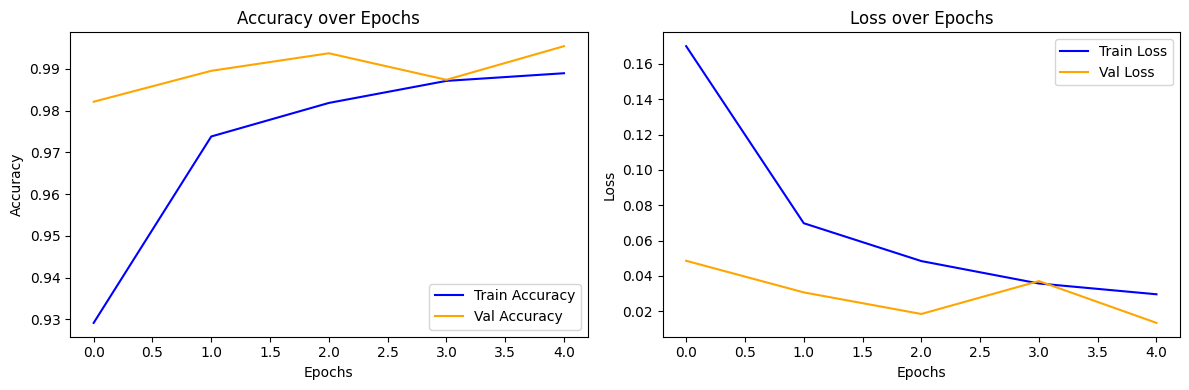

In [35]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'],  label='Train Accuracy', color='blue')
plt.plot(history['val_acc'],    label='Val Accuracy',   color='orange')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'],   label='Val Loss',   color='orange')
plt.title('Loss over Epochs')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

Evaluating on Test Set:   0%|          | 0/157 [00:00<?, ?it/s]

Test Accuracy : 99.41%
F1 Score      : 99.41%
AUC-ROC       : 0.9999

Detailed Report:
              precision    recall  f1-score   support

        fake       0.99      1.00      0.99     10000
        real       1.00      0.99      0.99     10000

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



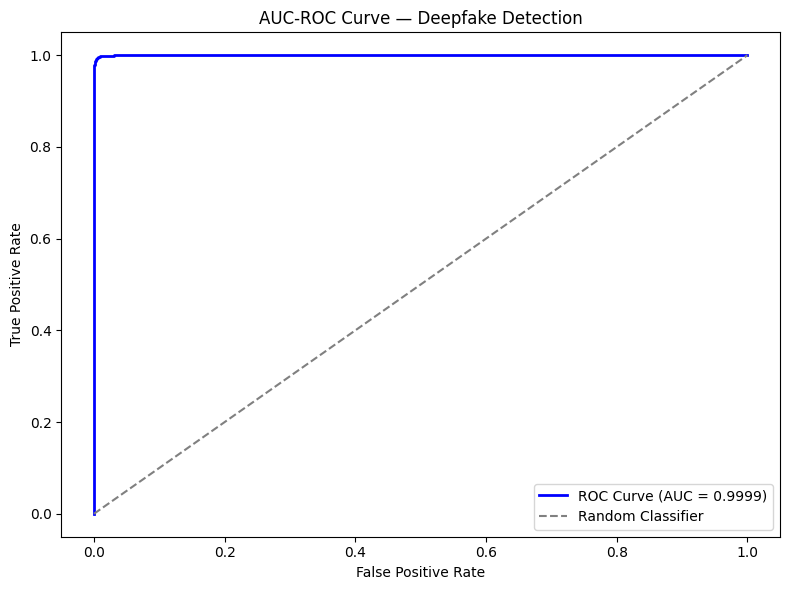

In [36]:
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, roc_curve

# Load best saved model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs   = torch.exp(outputs)

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds == all_labels).mean() * 100
f1       = f1_score(all_labels, all_preds, average='weighted') * 100
auc_roc  = roc_auc_score(all_labels, all_probs)

print(f"Test Accuracy : {accuracy:.2f}%")
print(f"F1 Score      : {f1:.2f}%")
print(f"AUC-ROC       : {auc_roc:.4f}")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve — Deepfake Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Predection Function

Prediction: fake (92.60% confidence)


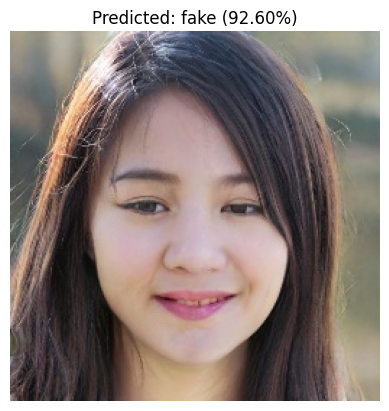

Prediction: real (100.00% confidence)


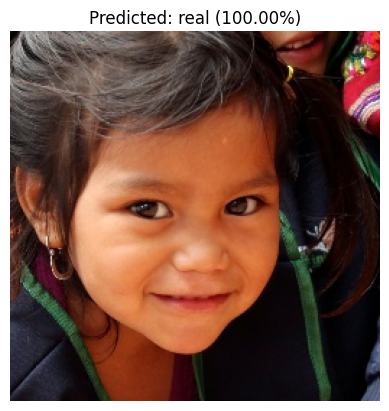

In [37]:
from PIL import Image
import torch.nn.functional as F

def predict_image(image_path):
    model.eval()
    img   = Image.open(image_path).convert('RGB')
    img_t = val_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_t)
        probs  = F.softmax(output, dim=1)
        conf, predicted = torch.max(probs, 1)

    label      = class_names[predicted.item()]
    confidence = conf.item() * 100
    print(f"Prediction: {label} ({confidence:.2f}% confidence)")

    plt.imshow(img)
    plt.title(f"Predicted: {label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

fake_path = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg'
real_path = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/real/00007.jpg'

predict_image(fake_path)
predict_image(real_path)

## Save Model

In [41]:
model_path = 'deepfake_detector_efficientnet_b0.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to deepfake_detector_efficientnet_b0.pth


In [44]:
for f in os.listdir('/kaggle/working/'):
    if f.endswith('.pth'):
        print(f)

best_model.pth
model.pth
